In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import time
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import tensorflow as tf
from joblib import Parallel, delayed
import statsmodels.api as sm

from concurrent.futures import ThreadPoolExecutor, as_completed


In [3]:
# !pip install cupy

In [4]:
sys.path.append('../src')
from search_utils import *

In [5]:
pd.reset_option('display.max_rows')

In [6]:
# !conda install cuml cupy-cuda11x

In [7]:

def get_bic_aic(k, X, init_params='kmeans'):
    if(init_params == 'gmm'):
        gmm = GaussianMixture(n_components = k)
    else:
        gmm = GaussianMixture(n_components = k, init_params = init_params)
    
    gmm.fit(X)
    return gmm.bic(X), gmm.aic(X)


def get_score_gmm(k, X):
    gmm = GaussianMixture(n_components = k, random_state=42)
    gmm.fit(X)
    y_pred = gmm.predict(X)
    
    inertia = gmm.inertia_
    bic, aic = get_bic_aic(k, X, init_params='gmm')    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    return k, inertia, bic, aic, sil, db, cal



In [8]:
def get_bic_aic(k, X, init_params='kmeans'):
    gmm = GaussianMixture(n_components=k, init_params=init_params).fit(X)

    return gmm.bic(X), gmm.aic(X)

def get_score_gmm(k, X,):
    gmm = GaussianMixture(n_components=k, random_state=42).fit(X)
    y_pred = gmm.predict(X)
    
    bic, aic = get_bic_aic(k, X, init_params='gmm')    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    return k, bic, aic, sil, db, cal

def get_score_gmm_covariance(k, X, covariance_type="full"):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type=covariance_type).fit(X)
    
    bic, aic = gmm.bic(X), gmm.aic(X) 
    y_pred = gmm.predict(X)

    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    return k, bic, aic, sil, db, cal

def get_score_gmm_covariance_time(k, X, covariance_type="full"):
    print("K: ", k)

    start_time = time.time()
    
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type=covariance_type).fit(X)
    
    end_time = time.time()
    fit_time = end_time - start_time
    
    bic, aic = gmm.bic(X), gmm.aic(X)
    y_pred = gmm.predict(X)
    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    print("Done K: ", k)

    return k, bic, aic, sil, db, cal, fit_time

def get_score_gmm_covariance_time_lite(k, X, covariance_type="full"):
    print("K: ", k)

    start_time = time.time()
    
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type=covariance_type).fit(X)
    
    end_time = time.time()
    fit_time = end_time - start_time
    
    bic, aic = gmm.bic(X), gmm.aic(X)
    y_pred = gmm.predict(X)
    
    sil = silhouette_score(X, y_pred)

    print("Done K: ", k)

    return k, bic, aic, sil, y_pred, fit_time


def get_score_gmm_covariance_silo_only(k, X, covariance_type="full"):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type=covariance_type).fit(X)
    print("K: ", k)

    # bic, aic = gmm.bic(X), gmm.aic(X) 
    y_pred = gmm.predict(X)

    sil = silhouette_score(X, y_pred)
    print("Done K: ", k)

    return k, sil

def get_score_gmm_covariance_lite(k, X, covariance_type="full"):
    print("K: ", k)

    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type=covariance_type).fit(X)
    
    bic, aic = gmm.bic(X), gmm.aic(X) 
    y_pred = gmm.predict(X)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    print("Done K: ", k)

    return k, bic, aic, db, cal


def get_score_kmeans(k, X):
    print("K: ", k)
    
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    y_pred = km.predict(X)
    
    inertia = km.inertia_
    bic, aic = get_bic_aic(k, X, init_params='kmeans')    
    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    print("Done K: ", k)

    return k, inertia, bic, aic, sil, db, cal

def get_score_kmeans_time(k, X):
    print("K: ", k)
    start_time = time.time()

    km = KMeans(n_clusters=k, random_state=42).fit(X)
    y_pred = km.predict(X)
    end_time = time.time()
    fit_time = end_time - start_time
    
    inertia = km.inertia_
    bic, aic = get_bic_aic(k, X, init_params='kmeans')    
    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    print("Done K: ", k)

    return k, inertia, bic, aic, sil, db, cal, fit_time

def get_score_kmeans_time_lite(k, X):
    print("K: ", k)
    start_time = time.time()

    km = KMeans(n_clusters=k, random_state=42).fit(X)
    end_time = time.time()
    fit_time = end_time - start_time
    
    y_pred = km.predict(X)
    inertia = km.inertia_
    
    bic, aic = get_bic_aic(k, X, init_params='kmeans')    
    sil = silhouette_score(X, y_pred)
    print("Done K: ", k)

    return k, inertia, bic, aic, sil, y_pred, fit_time

def get_score_kmeans_silo_only(k, X):
    print("K: ", k)
    
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    y_pred = km.predict(X)
    
    inertia = km.inertia_
    
    sil = silhouette_score(X, y_pred)
    print("Done K: ", k)

    return k, inertia, sil



def get_score_kmeans_lite(k, X):
    print("K: ", k)
    
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    y_pred = km.predict(X)
    
    inertia = km.inertia_
    bic, aic = get_bic_aic(k, X, init_params='kmeans')    
    
    db = davies_bouldin_score(X, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    print("Done K: ", k)

    return k, inertia, bic, aic, db, cal

def get_score_kmeans_simple(k, X):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    y_pred = km.predict(X)
    
    inertia = km.inertia_
    return k, inertia

In [9]:
def contrast(df, y1, y2):
    a = np.array(df[y1])
    b = np.array(df[y2])
    return a - b
def plot_contrast(infc, y1, y2, type):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    axx = ax1.twinx()
    
    x = infc['k']
    y1_values = infc[y1]
    y2_values = infc[y2]
    
    if type == 'min':
        contrast_values = contrast(infc, y1, y2)
        best_k = infc.loc[contrast_values.argmin(), 'k']
    elif type == 'max':
        contrast_values = contrast(infc, y1, y2)
        best_k = infc.loc[contrast_values.argmax(), 'k']
    else:
        raise ValueError("type must be either 'min' or 'max'")
    
    ax1.plot(x, y1_values, 'b-', label=y1)
    axx.plot(x, y2_values, 'r-', label=y2)
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel(y1, color='b')
    axx.set_ylabel(y2, color='r')
    
    ax2.plot(x, contrast_values, 'g-', label=f'{y1} - {y2}')
    ax2.axvline(best_k, color='k', linestyle='--', label=f'Best k = {best_k}')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel(f'{y1} - {y2}', color='g')
    
    fig.suptitle(f'Contrast Plot: {y1} vs {y2}')
    ax1.legend(loc='upper left')
    axx.legend(loc='upper right')
    ax2.legend(loc='upper left')
    
    plt.show()

In [10]:
def add_player_name_by_id(df_pbp):
    df_pbp = df_pbp.copy()
    players_df = pd.read_csv("players.csv")

    
    player_id_name = players_df.set_index("player_id_rg")["player_name"].to_dict()
    
    player_id_name.update(players_df.set_index("player_id_ao")["player_name"].to_dict())
    
    df_pbp["server_name"] = df_pbp["server_id"].map(player_id_name).fillna(df_pbp["server_id"])
    df_pbp["returner_name"] = df_pbp["returner_id"].map(player_id_name).fillna(df_pbp["returner_id"])
    
    df_pbp["point_winner_name"] = df_pbp["point_winner_id"].map(player_id_name).fillna(df_pbp["point_winner_id"])
    df_pbp["player1_name"] = df_pbp["player1"].map(player_id_name).fillna(df_pbp["player1"])
    df_pbp["player2_name"] = df_pbp["player2"].map(player_id_name).fillna(df_pbp["player2"])
    
    
    return df_pbp

In [11]:
def mirror_coords(df_pbp):
    '''
    Still keeps the ad and deuce courts separate but on a single side of the whole court
    '''
    df = df_pbp.copy()

    df['x_net_serve'] = df.apply(lambda row: -row['x_net_serve'] if row['x_ball_serve_impact'] > 0 else row['x_net_serve'], axis=1)
    df['x_serve_bounce'] = df.apply(lambda row: -row['x_serve_bounce'] if row['x_ball_serve_impact'] > 0 else row['x_serve_bounce'], axis=1)
    
    df['y_net_serve'] = df.apply(lambda row: -row['y_net_serve'] if row['x_ball_serve_impact'] > 0 else row['y_net_serve'], axis=1)
    df['y_serve_bounce'] = df.apply(lambda row: -row['y_serve_bounce'] if row['x_ball_serve_impact'] > 0 else row['y_serve_bounce'], axis=1)

    df_aux = df.copy()
    df_aux['x_ball_serve_impact'] = df_aux.apply(lambda row: -row['x_ball_serve_impact'] if row['x_ball_serve_impact'] > 0 else row['x_ball_serve_impact'], axis=1)
    
    df['y_ball_serve_impact'] = df.apply(lambda row: -row['y_ball_serve_impact'] if row['x_ball_serve_impact'] > 0 else row['y_ball_serve_impact'], axis=1)
    
    df['x_ball_serve_impact'] = df_aux['x_ball_serve_impact']
    
    return df

In [12]:
def is_successful_serve(row):
    return (row['is_ace'] == 1) or ((row['rally_length'] == 1) & (row['point_end_type'] == 'Forced Error') & (row['point_winner_name'] == row['server_name']))


In [13]:
players_df = pd.read_csv("players.csv")
all_players = players_df
players_df.iloc[players_df.loc[players_df['player_name'] == 'J.SINNER'].index[0]]

player_name      J.SINNER
player_id_ao      ATPS0AG
league                atp
player_id_rg        39723
country               ITA
player_id_atp        S0AG
avg_ranking         10.59
avg_points           5567
Name: 246, dtype: object

In [14]:
players_df

,player_name,player_id_ao,league,player_id_rg,country,player_id_atp,avg_ranking,avg_points
0,A.ANISIMOVA,WTA326384,wta,40607,USA,326384,0.00,0
1,A.BALAZS,ATPBD80,atp,15374,HUN,BD80,425.00,280
2,A.BARTY,WTA318033,wta,27902,AUS,318033,0.00,0
3,A.BEDENE,ATPBH09,atp,19666,SLO,BH09,189.14,610
4,A.BLINKOVA,WTA324267,wta,33614,RUS,324267,0.00,0
...,...,...,...,...,...,...,...,...
526,Z.BAI,WTA327196,wta,0,NaN,327196,0.00,0
527,Z.BERGS,ATPBU13,atp,36748,BEL,BU13,97.00,628
528,Z.DIYAS,WTA315696,wta,0,NaN,315696,0.00,0
529,Z.KOLAR,NaN,atp,34635,CZE,KH56,247.00,218


In [15]:
all_serves_ao = get_global_pbp_data_with_tracking_available("australian_open", "atp")
all_serves_rg = get_global_pbp_data_with_tracking_available("roland_garros", "atp")

all_serves_ao["tournament"] = "australian_open"

all_serves_rg["tournament"] = "roland_garros"

all_serves_ao.reset_index(drop=True, inplace=True)
all_serves_rg.reset_index(drop=True, inplace=True)

all_serves_pbp = pd.concat([all_serves_ao, all_serves_rg]).reset_index(drop=True)

tournament:  australian_open
league:  atp


Matches:  630
Points:  190417
tournament:  roland_garros
league:  atp
Matches:  321
Points:  75889


In [16]:
all_serves_pbp[all_serves_pbp['rank_points'].isna()]

,point_ID,set_num,game_num,point_num,serve_num,server_id,returner_id,point_winner_id,court_side,serve_speed_kph,...,returner_score,player1,player2,p1_cum_games,p2_cum_games,p1_cum_sets,p2_cum_sets,server_name,rank_points,tournament


In [17]:
all_serves_pbp = add_player_name_by_id(all_serves_pbp)
all_serves_pbp

,point_ID,set_num,game_num,point_num,serve_num,server_id,returner_id,point_winner_id,court_side,serve_speed_kph,...,p2_cum_games,p1_cum_sets,p2_cum_sets,server_name,rank_points,tournament,returner_name,point_winner_name,player1_name,player2_name
0,1_1_1_1,1,1,1,1,ATPN409,ATPDA31,NaN,DeuceCourt,0 KPH,...,0.0,0.0,0.0,R.NADAL,9850,australian_open,H.DELLIEN,Z.KOLAR,R.NADAL,H.DELLIEN
1,1_1_1_2,1,1,1,2,ATPN409,ATPDA31,ATPDA31,DeuceCourt,157 KPH,...,0.0,0.0,0.0,R.NADAL,9850,australian_open,H.DELLIEN,H.DELLIEN,R.NADAL,H.DELLIEN
2,1_1_2_1,1,1,2,1,ATPN409,ATPDA31,ATPN409,AdCourt,175 KPH,...,0.0,0.0,0.0,R.NADAL,9850,australian_open,H.DELLIEN,R.NADAL,R.NADAL,H.DELLIEN
3,1_1_3_1,1,1,3,1,ATPN409,ATPDA31,ATPN409,DeuceCourt,198 KPH,...,0.0,0.0,0.0,R.NADAL,9850,australian_open,H.DELLIEN,R.NADAL,R.NADAL,H.DELLIEN
4,1_1_4_1,1,1,4,1,ATPN409,ATPDA31,ATPN409,AdCourt,206 KPH,...,0.0,0.0,0.0,R.NADAL,9850,australian_open,H.DELLIEN,R.NADAL,R.NADAL,H.DELLIEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266301,3_10_1_1,3,10,1,1,39723.0,31798.0,39723.0,DeuceCourt,197 KPH,...,NaN,NaN,NaN,J.SINNER,1017,roland_garros,C.EUBANKS,J.SINNER,Z.KOLAR,Z.KOLAR
266302,3_10_4_1,3,10,4,1,39723.0,31798.0,31798.0,AdCourt,161 KPH,...,NaN,NaN,NaN,J.SINNER,1017,roland_garros,C.EUBANKS,C.EUBANKS,Z.KOLAR,Z.KOLAR
266303,3_10_5_1,3,10,5,1,39723.0,31798.0,39723.0,DeuceCourt,203 KPH,...,NaN,NaN,NaN,J.SINNER,1017,roland_garros,C.EUBANKS,J.SINNER,Z.KOLAR,Z.KOLAR
266304,3_10_6_1,3,10,6,1,39723.0,31798.0,39723.0,AdCourt,208.47 KPH,...,NaN,NaN,NaN,J.SINNER,1017,roland_garros,C.EUBANKS,J.SINNER,Z.KOLAR,Z.KOLAR


### Use caching

In [18]:
#joblib.dump(all_serves_pbp, 'all_serves_pbp.pkl')



In [19]:
#all_serves_pbp = joblib.load('all_serves_pbp.pkl')

### Optimal k components analysis

In [20]:
X = all_serves_pbp.copy()

In [21]:
def preprocess_serves(df, features):
    df = mirror_coords(df)
    serves_df = df.copy()
    og_serves_df = df.copy()
    og_features = list(og_serves_df.columns)
    
    # Assuming mirror_coords is a function you have defined
    
    
    # Convert 'serve_speed_kph' to numeric
    serves_df["serve_speed_kph"] = pd.to_numeric(serves_df["serve_speed_kph"].str.replace(" KPH", ""))
    
    serves_df = serves_df[serves_df['point_winner_id'].notna()]
    
    serves_df = serves_df[~((serves_df['is_fault'] == 1) & (serves_df['is_ace'] == 1))]
    
    # Filter out invalid values
    serves_df = serves_df[serves_df["serve_speed_kph"] > 0]
    
    serves_df = serves_df[serves_df["z_ball_serve_impact"] > 2]
    
    serves_df = serves_df[serves_df["z_ball_serve_impact"] < 5]
    
    serves_df = serves_df[serves_df["x_ball_serve_impact"] < -6.4]
    
    #serves_df = serves_df[serves_df["x_serve_bounce"] < 7]
    #serves_df_with_names = serves_df_with_names[serves_df_with_names["x_serve_bounce"] < 7]
    
    mask = (serves_df["x_serve_bounce"] > 7) & (serves_df["is_fault"] == 0)

    serves_df = serves_df[~mask]

    
    serves_df = serves_df[serves_df["x_serve_bounce"] > 1.5]

    # Filter out faults
    # serves_df = serves_df[serves_df["is_fault"] == 0]
    
    # Add server_name and returner_name to the features
    features_with_names = features.copy()
    features_with_names.extend(["server_name", "returner_name"])
    
    # Filter the DataFrames with the features
    serves_df_with_names = serves_df[features_with_names]
    serves_df = serves_df[features]
    
    # Check for NaN values before removing them
    print("Columns with NaN values in serves_df:")
    print(serves_df.isna().sum()[serves_df.isna().sum() > 0])
    print("\nColumns with NaN values in serves_df_with_names:")
    print(serves_df_with_names.isna().sum()[serves_df_with_names.isna().sum() > 0])
    
    # Separate numeric columns
    numeric_columns = serves_df.select_dtypes(exclude=['object']).columns
    print("numeric_columns: ", numeric_columns)
    
    # Drop rows with NaN values
    serves_df.dropna(inplace=True)
    serves_df_with_names.dropna(inplace=True)
    
    # Encode categorical columns
    label_encoder = LabelEncoder()
    categorical_columns = ['court_side', 'serve_dir', 'serve_type']
    for col in categorical_columns:
        serves_df[col] = label_encoder.fit_transform(serves_df[col])
    
    
    
    # Add the original features back to the preprocessed DataFrame
    saved_og_indices = serves_df.index
    serves_df_with_names = serves_df_with_names.loc[saved_og_indices]
    serves_df_with_names[og_features] = df.loc[saved_og_indices, og_features]
    
    serves_df_with_names["serve_speed_kph"] = pd.to_numeric(serves_df_with_names["serve_speed_kph"].str.replace(" KPH", ""))

    return serves_df, serves_df_with_names

In [22]:
X = all_serves_pbp.copy()
features_serves_in = ["court_side","serve_dir","serve_speed_kph","serve_type",
            "x_ball_serve_impact","y_ball_serve_impact","z_ball_serve_impact",
            "z_net_serve","x_net_serve","y_net_serve","x_serve_bounce","y_serve_bounce","z_serve_bounce"]

X = X.reset_index(drop=True)
duplicate_indices = X.index[X.index.duplicated()]
if not duplicate_indices.empty:
    print(f"Duplicate indices: {duplicate_indices}")

X, serves_df_with_names = preprocess_serves(X, features_serves_in)

Columns with NaN values in serves_df:
serve_type      8351
z_net_serve    68800
x_net_serve    68800
y_net_serve    68800
dtype: int64

Columns with NaN values in serves_df_with_names:
serve_type      8351
z_net_serve    68800
x_net_serve    68800
y_net_serve    68800
dtype: int64
numeric_columns:  Index(['serve_speed_kph', 'x_ball_serve_impact', 'y_ball_serve_impact',
       'z_ball_serve_impact', 'z_net_serve', 'x_net_serve', 'y_net_serve',
       'x_serve_bounce', 'y_serve_bounce', 'z_serve_bounce'],
      dtype='object')


In [23]:
X

,court_side,serve_dir,serve_speed_kph,serve_type,x_ball_serve_impact,y_ball_serve_impact,z_ball_serve_impact,z_net_serve,x_net_serve,y_net_serve,x_serve_bounce,y_serve_bounce,z_serve_bounce
1,1,1,157.00,2,-11.619,-0.617,2.956,1.108,0.0,0.589,4.469,0.824,0.035
2,0,2,175.00,2,-11.342,1.027,2.790,1.081,0.0,-1.890,4.845,-3.327,0.033
3,1,1,198.00,2,-11.358,-0.287,2.820,1.097,0.0,0.725,5.372,1.161,0.033
4,0,1,206.00,1,-11.499,0.714,2.831,1.100,0.0,-0.648,5.479,-1.331,0.033
6,1,2,164.00,2,-11.469,-0.523,2.896,0.972,0.0,2.295,9.478,4.615,0.031
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266301,1,2,197.00,0,-11.167,-0.901,2.855,1.104,-0.0,2.313,5.105,3.918,0.037
266302,0,1,161.00,0,-11.096,1.207,2.887,1.126,-0.0,0.421,5.232,0.125,0.059
266303,1,1,203.00,0,-11.220,-0.808,2.877,1.180,-0.0,0.117,5.773,0.623,0.057
266304,0,2,208.47,2,-11.041,1.230,2.875,1.331,-0.0,-1.886,6.911,-3.833,0.036


In [24]:
serves_df_with_names[serves_df_with_names['is_fault'] == 0]

,court_side,serve_dir,serve_speed_kph,serve_type,x_ball_serve_impact,y_ball_serve_impact,z_ball_serve_impact,z_net_serve,x_net_serve,y_net_serve,...,player2,p1_cum_games,p2_cum_games,p1_cum_sets,p2_cum_sets,rank_points,tournament,point_winner_name,player1_name,player2_name
1,DeuceCourt,T,157.0,Pronated,-11.619,-0.617,2.956,1.108,0.0,0.589,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,H.DELLIEN,R.NADAL,H.DELLIEN
2,AdCourt,Wide,175.0,Pronated,-11.342,1.027,2.790,1.081,0.0,-1.890,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
3,DeuceCourt,T,198.0,Pronated,-11.358,-0.287,2.820,1.097,0.0,0.725,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
4,AdCourt,T,206.0,Kick,-11.499,0.714,2.831,1.100,0.0,-0.648,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
8,AdCourt,T,165.0,Pronated,-11.451,0.922,2.903,0.961,0.0,-0.182,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266300,AdCourt,Wide,181.0,Flat,-10.937,0.850,3.025,1.049,0.0,-2.217,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,C.EUBANKS,Z.KOLAR,Z.KOLAR
266301,DeuceCourt,Wide,197.0,Flat,-11.167,-0.901,2.855,1.104,-0.0,2.313,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266302,AdCourt,T,161.0,Flat,-11.096,1.207,2.887,1.126,-0.0,0.421,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,C.EUBANKS,Z.KOLAR,Z.KOLAR
266303,DeuceCourt,T,203.0,Flat,-11.220,-0.808,2.877,1.180,-0.0,0.117,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR


In [25]:
serves_df_with_names[serves_df_with_names['is_fault'] == 1]

,court_side,serve_dir,serve_speed_kph,serve_type,x_ball_serve_impact,y_ball_serve_impact,z_ball_serve_impact,z_net_serve,x_net_serve,y_net_serve,...,player2,p1_cum_games,p2_cum_games,p1_cum_sets,p2_cum_sets,rank_points,tournament,point_winner_name,player1_name,player2_name
6,DeuceCourt,Wide,164.00,Pronated,-11.469,-0.523,2.896,0.972,0.0,2.295,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,H.DELLIEN,R.NADAL,H.DELLIEN
18,AdCourt,Wide,147.00,Unclassified,-11.208,1.398,2.788,0.951,0.0,-2.033,...,ATPDA31,1.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
132,DeuceCourt,Wide,169.00,Pronated,-11.575,-0.528,2.941,1.423,-0.0,2.383,...,ATPDA31,4.0,2.0,1.0,0.0,9850,australian_open,H.DELLIEN,R.NADAL,H.DELLIEN
289,DeuceCourt,Wide,155.00,Slice,-11.484,-0.718,2.887,1.512,0.0,1.727,...,ATPSH90,0.0,0.0,1.0,0.0,825,australian_open,F.DELBONIS,F.DELBONIS,J.SOUSA
291,AdCourt,Body,151.00,Pronated,-11.479,1.227,2.893,0.943,0.0,-0.318,...,ATPSH90,0.0,0.0,1.0,0.0,825,australian_open,F.DELBONIS,F.DELBONIS,J.SOUSA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266258,AdCourt,Body,198.06,Flat,-11.026,2.901,2.997,1.361,-0.0,0.072,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266263,AdCourt,Wide,199.31,Flat,-11.138,0.905,3.057,1.271,-0.0,-2.654,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266273,DeuceCourt,T,198.97,Flat,-11.037,-0.682,3.043,1.359,-0.0,0.307,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266296,AdCourt,T,194.45,Flat,-11.016,1.108,3.022,1.343,-0.0,-0.228,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR


In [26]:
serves_df_with_names

,court_side,serve_dir,serve_speed_kph,serve_type,x_ball_serve_impact,y_ball_serve_impact,z_ball_serve_impact,z_net_serve,x_net_serve,y_net_serve,...,player2,p1_cum_games,p2_cum_games,p1_cum_sets,p2_cum_sets,rank_points,tournament,point_winner_name,player1_name,player2_name
1,DeuceCourt,T,157.00,Pronated,-11.619,-0.617,2.956,1.108,0.0,0.589,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,H.DELLIEN,R.NADAL,H.DELLIEN
2,AdCourt,Wide,175.00,Pronated,-11.342,1.027,2.790,1.081,0.0,-1.890,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
3,DeuceCourt,T,198.00,Pronated,-11.358,-0.287,2.820,1.097,0.0,0.725,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
4,AdCourt,T,206.00,Kick,-11.499,0.714,2.831,1.100,0.0,-0.648,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,R.NADAL,R.NADAL,H.DELLIEN
6,DeuceCourt,Wide,164.00,Pronated,-11.469,-0.523,2.896,0.972,0.0,2.295,...,ATPDA31,0.0,0.0,0.0,0.0,9850,australian_open,H.DELLIEN,R.NADAL,H.DELLIEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266301,DeuceCourt,Wide,197.00,Flat,-11.167,-0.901,2.855,1.104,-0.0,2.313,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266302,AdCourt,T,161.00,Flat,-11.096,1.207,2.887,1.126,-0.0,0.421,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,C.EUBANKS,Z.KOLAR,Z.KOLAR
266303,DeuceCourt,T,203.00,Flat,-11.220,-0.808,2.877,1.180,-0.0,0.117,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR
266304,AdCourt,Wide,208.47,Pronated,-11.041,1.230,2.875,1.331,-0.0,-1.886,...,NaN,NaN,NaN,NaN,NaN,1017,roland_garros,J.SINNER,Z.KOLAR,Z.KOLAR


In [27]:
joblib.dump(X, 'X.pkl')


['X.pkl']

#### Kmeans K

In [47]:
def compare_clusters_scores(infc_kmeans, infc_gmm, elbow=True, silhouette=False, aic_bic_separate=True, davies=True, calinski=True,
                            save_eps=False, save_pdf=False, save_png=False):
    
    plt.figure(figsize=(14, 10))
    if (elbow):
        plt.subplot(2, 3, 1)
        #plt.figure(figsize=(10, 6))
        plt.plot(infc_kmeans['k'], infc_kmeans['inertia'], marker='o')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Inertia')
        plt.title('Elbow Method for Optimal k')
        plt.grid(True)


    if (aic_bic_separate):
        # BIC comparison
        plt.subplot(2, 3, 2)
        plt.plot(infc_kmeans['k'], infc_kmeans['BIC'], marker='o', label='KMeans BIC')
        plt.plot(infc_gmm['k'], infc_gmm['BIC'], marker='o', label='GMM BIC')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('BIC Score')
        plt.title('BIC Score Comparison')
        plt.legend()
        plt.grid(True)

        # AIC comparison
        plt.subplot(2, 3, 3)
        plt.plot(infc_kmeans['k'], infc_kmeans['AIC'], marker='o', label='KMeans AIC')
        plt.plot(infc_gmm['k'], infc_gmm['AIC'], marker='o', label='GMM AIC')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('AIC Score')
        plt.title('AIC Score Comparison')
        plt.legend()
        plt.grid(True)
    else:
        
        plt.subplot(2, 3, 2)

        plt.plot(infc_gmm['k'], infc_gmm['BIC'], marker='o', label='GMM BIC')
        plt.plot(infc_gmm['k'], infc_gmm['AIC'], marker='x', label='GMM AIC')
        plt.plot(infc_kmeans['k'], infc_kmeans['BIC'], marker='^', label='KMeans BIC')
        plt.plot(infc_kmeans['k'], infc_kmeans['AIC'], marker='x', label='KMeans AIC')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('AIC and BIC Score')
        plt.title('AIC and BIC Score Comparison')
        plt.legend()
        plt.grid(True)

        



    if (silhouette):
    # Silhouette comparison
        if (aic_bic_separate):
            plt.subplot(2, 3, 4)
        else:
            plt.subplot(2, 3, 3)

        plt.plot(infc_kmeans['k'], infc_kmeans['silhouette'], marker='o', label='KMeans Silhouette')
        plt.plot(infc_gmm['k'], infc_gmm['silhouette'], marker='o', label='GMM Silhouette')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Silhouette Score')
        plt.title('Silhouette Score Comparison')
        plt.legend()
        plt.grid(True)

        
    if (davies):
        # Davies-Bouldin comparison
        plt.subplot(2, 3, 5)
        plt.plot(infc_kmeans['k'], infc_kmeans['davies'], marker='o', label='KMeans Davies-Bouldin')
        plt.plot(infc_gmm['k'], infc_gmm['davies'], marker='o', label='GMM Davies-Bouldin')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Davies-Bouldin Score')
        plt.title('Davies-Bouldin Score Comparison')
        plt.legend()
        plt.grid(True)

    if (calinski):
        # Calinski-Harabasz comparison
        plt.subplot(2, 3, 6)
        plt.plot(infc_kmeans['k'], infc_kmeans['calinski'], marker='o', label='KMeans Calinski-Harabasz')
        plt.plot(infc_gmm['k'], infc_gmm['calinski'], marker='o', label='GMM Calinski-Harabasz')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Calinski-Harabasz Score')
        plt.title('Calinski-Harabasz Score Comparison')
        plt.legend()
        plt.grid(True)
    
    if save_eps:
        plt.savefig(save_eps, format='eps')
    if save_pdf:
        plt.savefig(save_pdf, format='pdf', bbox_inches='tight')
        
    if save_png:
        plt.savefig(save_png, format='png', bbox_inches='tight', transparent=True)
    
    
    
    
def compare_all_clusters_scores(infc_kmeans, infc_gmm_full, infc_gmm_tied, infc_gmm_diag, infc_gmm_spherical, silhouette=False):
    # Plotting the comparison
    plt.figure(figsize=(20, 15))

    gmm_covariances = {
        "GMM Full": infc_gmm_full,
        "GMM Tied": infc_gmm_tied,
        "GMM Diag": infc_gmm_diag,
        "GMM Spherical": infc_gmm_spherical
    }

    # Define the elbow points
    elbows = {
        "KMeans": (6, infc_kmeans.loc[infc_kmeans['k'] == 6]),
        "GMM Full": (7, infc_gmm_full.loc[infc_gmm_full['k'] == 7]),
        "GMM Tied": (8, infc_gmm_tied.loc[infc_gmm_tied['k'] == 8]),
        "GMM Diag": (6, infc_gmm_diag.loc[infc_gmm_diag['k'] == 6]),
        "GMM Spherical": (5, infc_gmm_spherical.loc[infc_gmm_spherical['k'] == 5])
    }

    # BIC comparison
    plt.subplot(2, 3, 1)
    kmeans_bic_score = elbows["KMeans"][1]['BIC'].values[0]
    plt.plot(infc_kmeans['k'], infc_kmeans['BIC'], marker='o', label=f'KMeans BIC (Elbow at K={elbows["KMeans"][0]}, Score={kmeans_bic_score:.2f})')
    for label, df in gmm_covariances.items():
        elbow_k, elbow_values = elbows[label]
        score = elbow_values['BIC'].values[0]
        plt.plot(df['k'], df['BIC'], marker='o', label=f'{label} BIC (Elbow at K={elbow_k}, Score={score:.2f})')
        plt.plot([elbow_k, elbow_k], [0, score], linestyle='--', color='black')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('BIC Score')
    plt.title('BIC Score Comparison (Lower Better)')
    plt.legend()
    plt.grid(True)

    # AIC comparison
    plt.subplot(2, 3, 2)
    kmeans_aic_score = elbows["KMeans"][1]['AIC'].values[0]
    plt.plot(infc_kmeans['k'], infc_kmeans['AIC'], marker='o', label=f'KMeans AIC (Elbow at K={elbows["KMeans"][0]}, Score={kmeans_aic_score:.2f})')
    for label, df in gmm_covariances.items():
        elbow_k, elbow_values = elbows[label]
        score = elbow_values['AIC'].values[0]
        plt.plot(df['k'], df['AIC'], marker='o', label=f'{label} AIC (Elbow at K={elbow_k}, Score={score:.2f})')
        plt.plot([elbow_k, elbow_k], [0, score], linestyle='--', color='black')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('AIC Score')
    plt.title('AIC Score Comparison (Lower Better)')
    plt.legend()
    plt.grid(True)

    if (silhouette):
    # # Silhouette comparison
        plt.subplot(2, 3, 3)
        kmeans_silhouette_score = elbows["KMeans"][1]['silhouette'].values[0]
        plt.plot(infc_kmeans['k'], infc_kmeans['silhouette'], marker='o', label=f'KMeans Silhouette (Elbow at K={elbows["KMeans"][0]}, Score={kmeans_silhouette_score:.2f})')
        for label, df in gmm_covariances.items():
            elbow_k, elbow_values = elbows[label]
            score = elbow_values['silhouette'].values[0]
            plt.plot(df['k'], df['silhouette'], marker='o', label=f'{label} Silhouette (Elbow at K={elbow_k}, Score={score:.2f})')
            plt.plot([elbow_k, elbow_k], [0, score], linestyle='--', color='black')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Silhouette Score')
        plt.title('Silhouette Score Comparison')
        plt.legend()
        plt.grid(True)

    # Davies-Bouldin comparison
    plt.subplot(2, 3, 4)
    kmeans_davies_score = elbows["KMeans"][1]['davies'].values[0]
    plt.plot(infc_kmeans['k'], infc_kmeans['davies'], marker='o', label=f'KMeans Davies-Bouldin (Elbow at K={elbows["KMeans"][0]}, Score={kmeans_davies_score:.2f})')
    for label, df in gmm_covariances.items():
        elbow_k, elbow_values = elbows[label]
        score = elbow_values['davies'].values[0]
        plt.plot(df['k'], df['davies'], marker='o', label=f'{label} Davies-Bouldin (Elbow at K={elbow_k}, Score={score:.2f})')
        plt.plot([elbow_k, elbow_k], [0, score], linestyle='--', color='black')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Davies-Bouldin Score')
    plt.title('Davies-Bouldin Score Comparison (Lower Better)')
    plt.legend()
    plt.grid(True)

    # Calinski-Harabasz comparison
    plt.subplot(2, 3, 5)
    kmeans_calinski_score = elbows["KMeans"][1]['calinski'].values[0]
    plt.plot(infc_kmeans['k'], infc_kmeans['calinski'], marker='o', label=f'KMeans Calinski-Harabasz (Elbow at K={elbows["KMeans"][0]}, Score={kmeans_calinski_score:.2f})')
    for label, df in gmm_covariances.items():
        elbow_k, elbow_values = elbows[label]
        score = elbow_values['calinski'].values[0]
        plt.plot(df['k'], df['calinski'], marker='o', label=f'{label} Calinski-Harabasz (Elbow at K={elbow_k}, Score={score:.2f})')
        plt.plot([elbow_k, elbow_k], [0, score], linestyle='--', color='black')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Calinski-Harabasz Score')
    plt.title('Calinski-Harabasz Score Comparison (Higher Better)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [29]:
def compute_scores_kmeans(k, X):
    return get_score_kmeans_time_lite(k, X)

def compute_scores_gmm(k, X, covariance_type):
    return get_score_gmm_covariance_time_lite(k, X, covariance_type=covariance_type)

def parallel_compute(func, k_range, *args):
    num_workers = 8
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(func, k, *args) for k in k_range]
        return [future.result() for future in as_completed(futures)]



### Compute Results (Uncomment to use)

In [30]:
k_range = range(2, 61)


In [31]:
# infc_kmeans = pd.DataFrame(parallel_compute(compute_scores_kmeans, k_range, X), 
#                            columns=['k', 'inertia', 'BIC', 'AIC', 'silhouette', 'y_pred', 'fit_time'])

In [32]:
# Compute all GMM models
# covariance_types = ['full', 'spherical', 'diag', 'tied']
# infc_gmm = {cov: pd.DataFrame(parallel_compute(compute_scores_gmm, k_range, X, cov), 
#                               columns=['k', 'BIC', 'AIC', 'silhouette', 'y_pred', 'fit_time']) for cov in covariance_types}

### Save Results

In [33]:
# # Save results
# joblib.dump(infc_kmeans, 'infc_kmeans_serv_n_dead.pkl')
# joblib.dump(infc_kmeans_scaled, 'infc_kmeans_serv_n_dead_scaled.pkl')
# joblib.dump(infc_kmeans_scaled_silo_only, 'infc_kmeans_serv_n_dead_silo_scaled.pkl')

# for cov, df in infc_gmm.items():
#     joblib.dump(df, f'infc_gmm_{cov}_serv_n_dead.pkl')

# for cov, df in infc_gmm_scaled.items():
#     joblib.dump(df, f'infc_gmm_{cov}_serv_n_dead_scaled.pkl')


### Load Results

In [34]:
infc_kmeans_no_scale = joblib.load('infc_kmeans_serv_n_dead.pkl')

infc_kmeans_no_scale_silo = joblib.load('infc_kmeans_serv_n_dead_silo.pkl')
infc_gmm_full_silo = joblib.load('infc_gmm_full_serv_n_dead_silo.pkl')

infc_gmm_full = joblib.load('infc_gmm_full_serv_n_dead.pkl')

infc_gmm_tied = joblib.load('infc_gmm_tied_serv_n_dead.pkl')
infc_gmm_diag = joblib.load('infc_gmm_diag_serv_n_dead.pkl')
infc_gmm_spherical = joblib.load('infc_gmm_spherical_serv_n_dead.pkl')

infc_kmeans_no_scale_time = joblib.load('infc_kmeans_no_scale_time.pkl')
infc_gmm_full_no_scale_time = joblib.load('infc_gmm_full_no_scale_time.pkl')

infc_gmm_serv_no_scale_fault = joblib.load('infc_gmm_serv_no_scale_fault.pkl')
infc_kmeans_serv_no_scale_fault = joblib.load('infc_kmeans_serv_no_scale_fault.pkl')

In [35]:
infc_kmeans_no_scale.reset_index(drop=True, inplace=True)
infc_kmeans_no_scale_silo.reset_index(drop=True, inplace=True)

infc_gmm_full.reset_index(drop=True, inplace=True)
infc_gmm_full_silo.reset_index(drop=True, inplace=True)
infc_gmm_full_no_scale_time.reset_index(drop=True, inplace=True)

In [36]:
infc_kmeans_no_scale['silhouette'] = infc_kmeans_no_scale_silo['silhouette']

### No Scaling

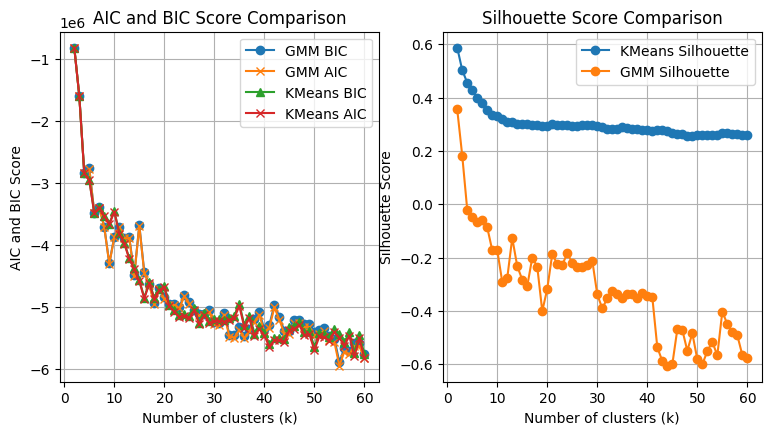

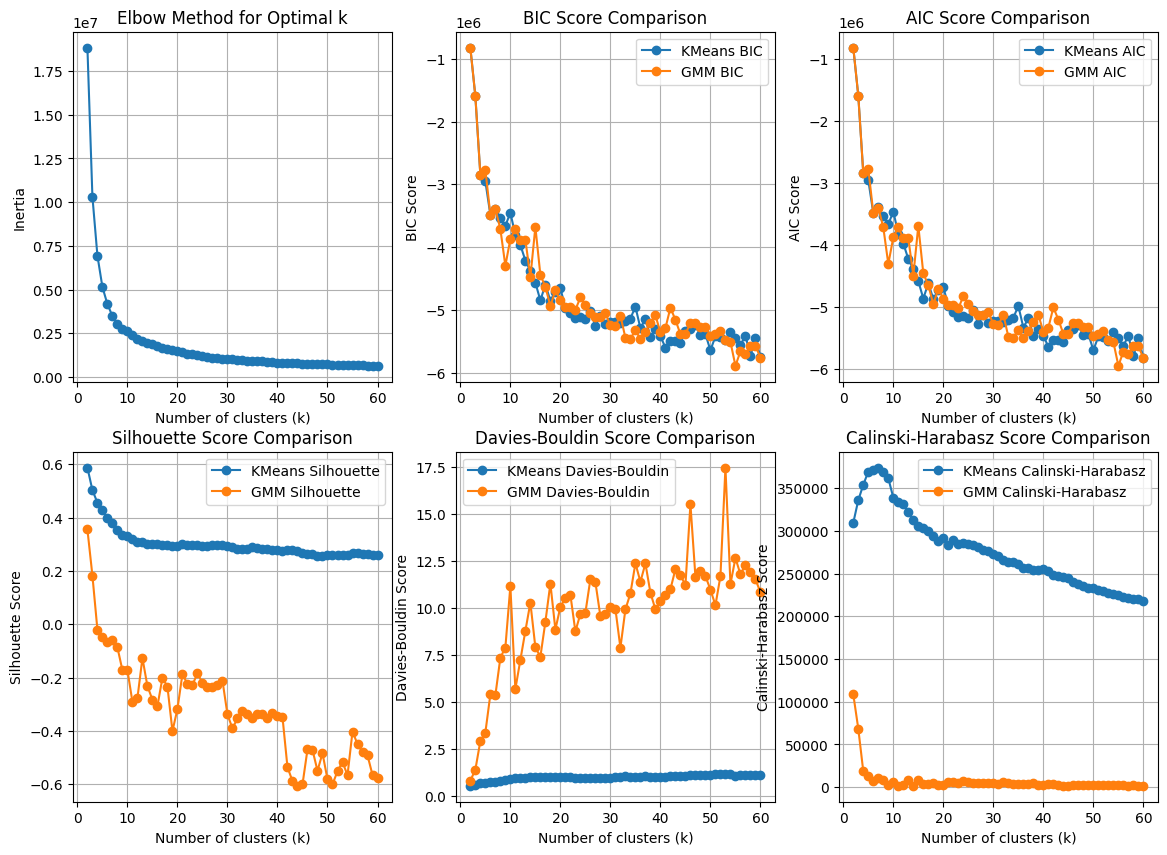

In [51]:
# compare_clusters_scores(infc_kmeans_no_scale, infc_gmm_full, silhouette=False)
compare_clusters_scores(infc_kmeans_no_scale_silo, infc_gmm_full_silo, elbow=False, silhouette=True, aic_bic_separate=False, davies=False, calinski=False, save_pdf="scores_kmeans_vs_gmm.pdf")
compare_clusters_scores(infc_kmeans_no_scale_silo, infc_gmm_full_silo, silhouette=True, aic_bic_separate=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


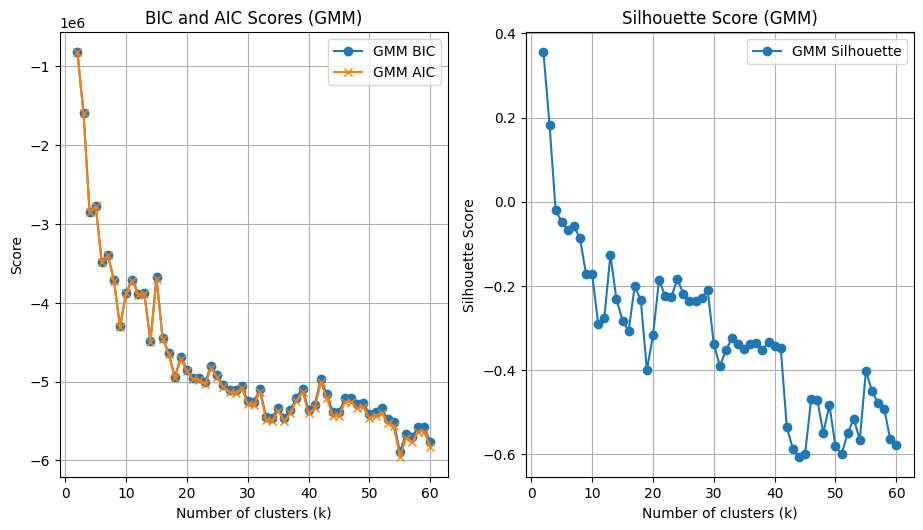

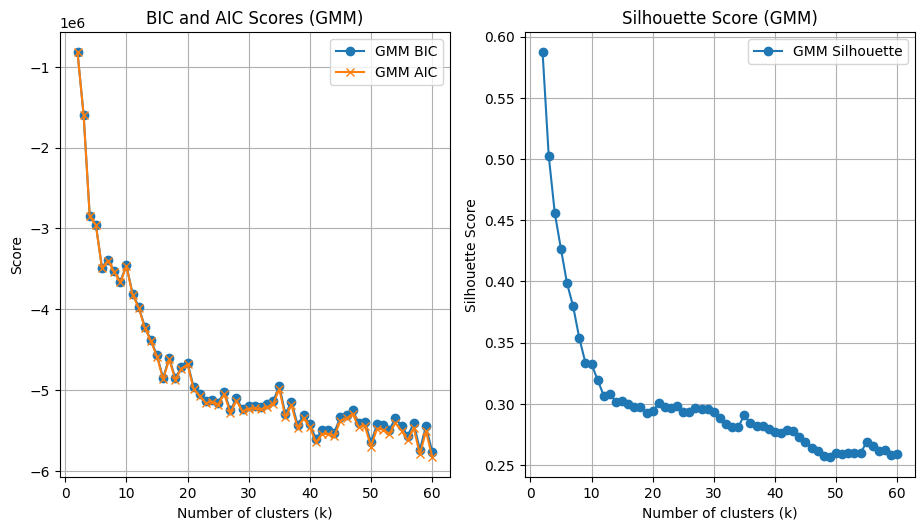

In [38]:
def plot_gmm_scores(infc_gmm, silhouette=False, fit_time=False, save_eps=None, save_pdf=None, save_png=None):
    plt.figure(figsize=(14, 10))
    
    plt.subplot(2, 3, 1)
    plt.plot(infc_gmm['k'], infc_gmm['BIC'], marker='o', label='GMM BIC')
    plt.plot(infc_gmm['k'], infc_gmm['AIC'], marker='x', label='GMM AIC')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Score')
    plt.title('BIC and AIC Scores (GMM)')
    plt.legend()
    plt.grid(True)

    if silhouette:
        # Silhouette comparison
        plt.subplot(2, 3, 2)
        plt.plot(infc_gmm['k'], infc_gmm['silhouette'], marker='o', label='GMM Silhouette')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Silhouette Score')
        plt.title('Silhouette Score (GMM)')
        plt.legend()
        plt.grid(True)

    # Davies-Bouldin comparison
    # plt.subplot(2, 3, 3)
    # plt.plot(infc_gmm['k'], infc_gmm['davies'], marker='o', label='GMM Davies-Bouldin')
    # plt.xlabel('Number of clusters (k)')
    # plt.ylabel('Davies-Bouldin Score')
    # plt.title('Davies-Bouldin Score (GMM)')
    # plt.legend()
    # plt.grid(True)

    # # Calinski-Harabasz comparison
    # plt.subplot(2, 3, 4)
    # plt.plot(infc_gmm['k'], infc_gmm['calinski'], marker='o', label='GMM Calinski-Harabasz')
    # plt.xlabel('Number of clusters (k)')
    # plt.ylabel('Calinski-Harabasz Score')
    # plt.title('Calinski-Harabasz Score (GMM)')
    # plt.legend()
    # plt.grid(True)
    
    if fit_time:
        plt.subplot(2, 3, 3)
        plt.plot(infc_gmm['k'], infc_gmm['fit_time'], marker='o', label='GMM Fit Time')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Fit Time (seconds)')
        plt.title('Fit Time (GMM)')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    

    if save_eps:
        plt.savefig(save_eps, format='eps')
    if save_pdf:
        plt.savefig(save_pdf, format='pdf', bbox_inches='tight')
        
    if save_png:
        plt.savefig(save_png, format='png', bbox_inches='tight', transparent=True)

    
plot_gmm_scores(infc_gmm_full_silo, silhouette=True, save_eps="scores_gmm_full_silo.eps")
plot_gmm_scores(infc_kmeans_no_scale_silo, silhouette=True, save_eps="scores_infc_kmeans_no_scale_silo.eps")
# plot_gmm_scores(infc_gmm_full_silo, silhouette=True, save_pdf="gmm_scores_aic_bic_silo.pdf")
# plot_gmm_scores(infc_gmm_full_silo, silhouette=True, save_png="gmm_scores_aic_bic_silo.png")

pos 2


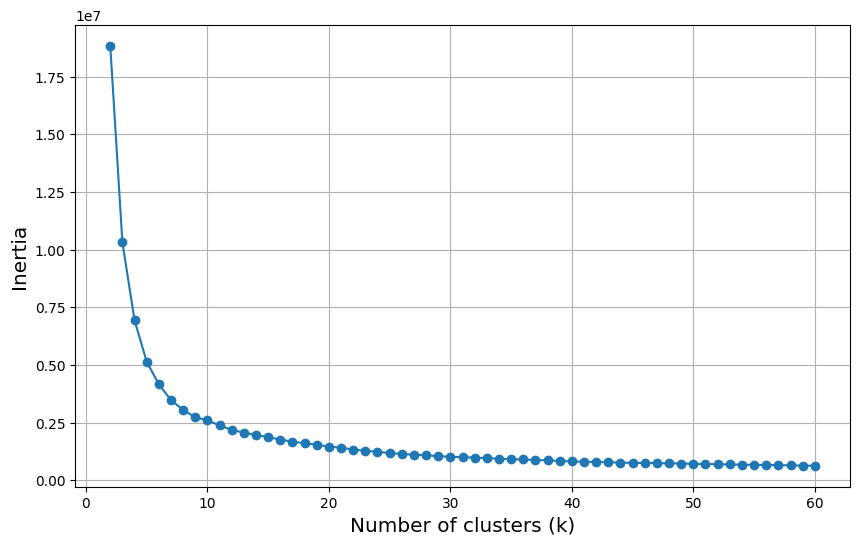

In [39]:
infc_kmeans_no_scale
pos = (infc_kmeans_no_scale[['k', 'inertia']]**2).sum(axis = 1).idxmin()
derivatives = np.diff(infc_kmeans_no_scale['inertia'], 2)
pos = np.argmax(derivatives) + 2  
print("pos", pos)


plt.figure(figsize=(10, 6))
plt.plot(infc_kmeans_no_scale['k'], infc_kmeans_no_scale['inertia'], marker='o')
plt.xlabel('Number of clusters (k)', fontsize='x-large')
plt.ylabel('Inertia', fontsize='x-large')
#plt.title('Elbow Method for Optimal k', fontsize='x-large')
plt.grid(True)
plt.savefig("elbow_kmeans.eps", format='eps')
plt.savefig("elbow_kmeans.pdf", format='pdf', bbox_inches='tight')
plt.savefig("elbow_kmeans.png", format='png', bbox_inches='tight', transparent=True)

plt.show()


### Test all covariances

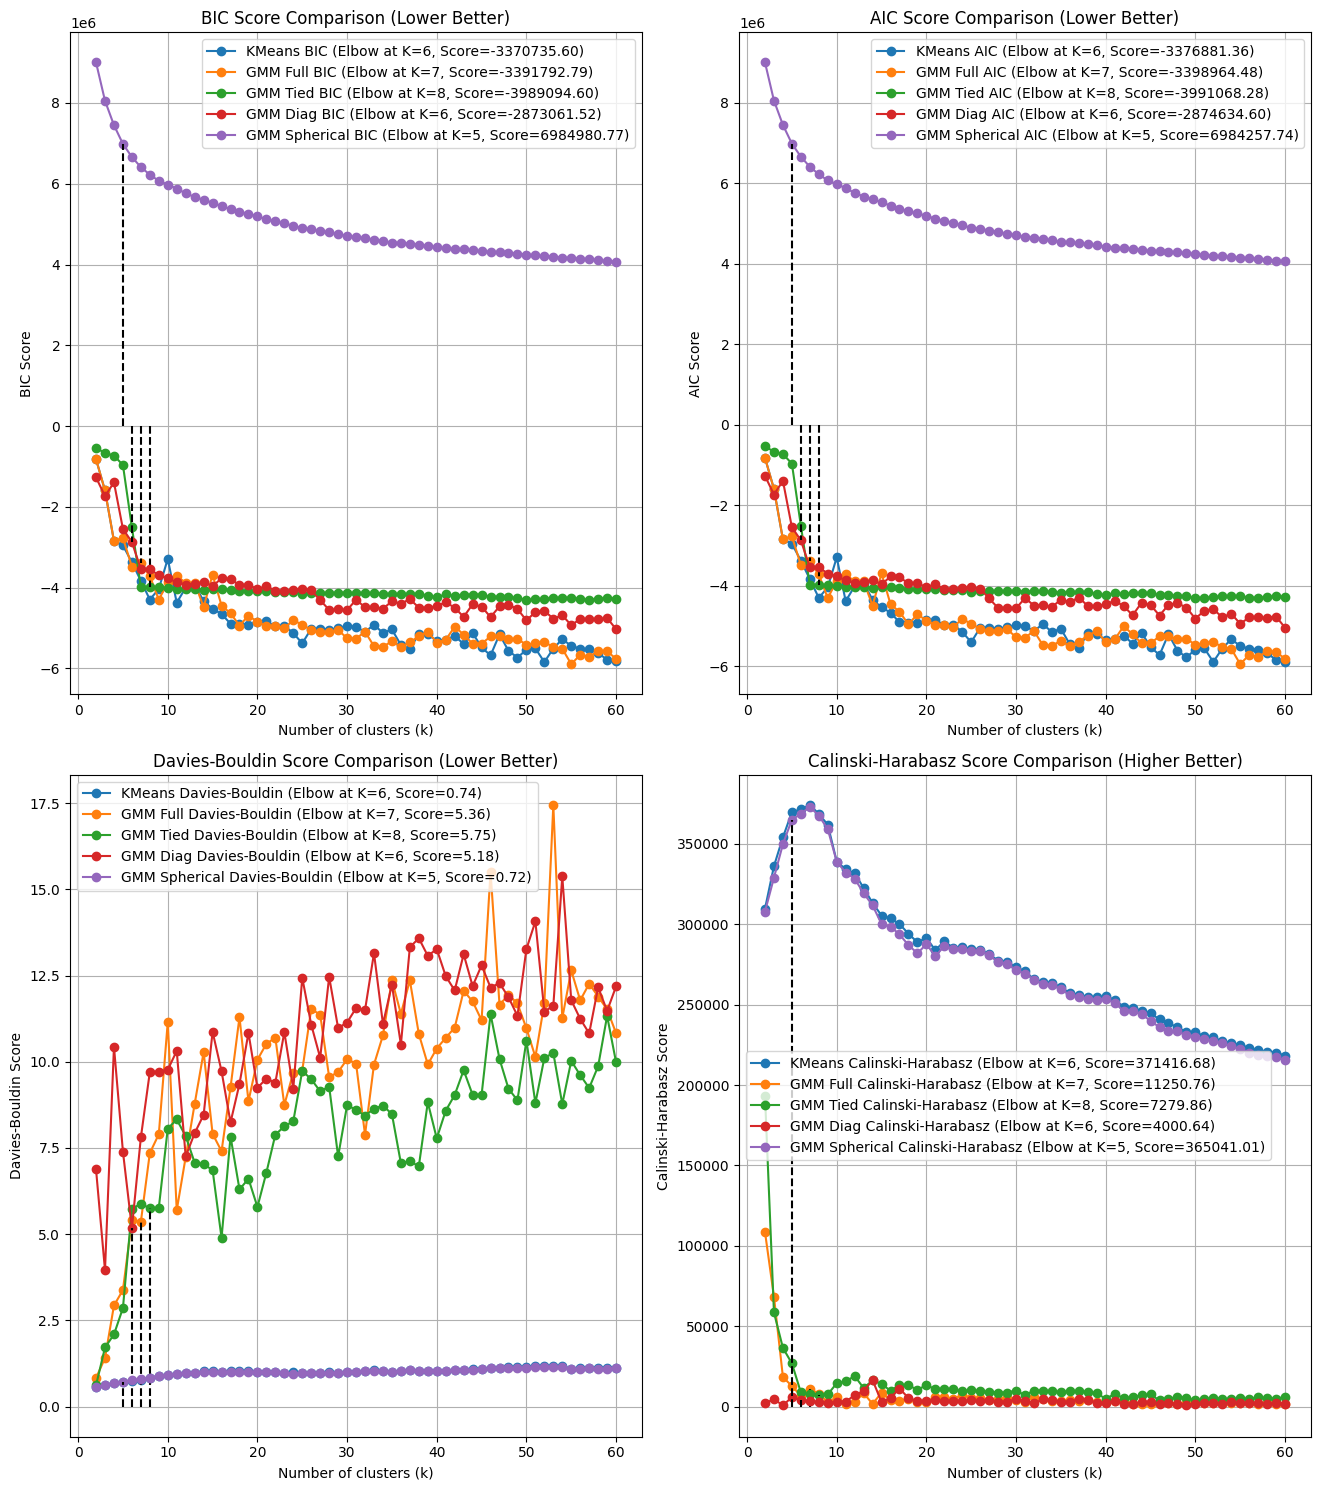

In [40]:
compare_all_clusters_scores(infc_kmeans_no_scale, infc_gmm_full, infc_gmm_tied, infc_gmm_diag, infc_gmm_spherical)

### Kmeans Contrast

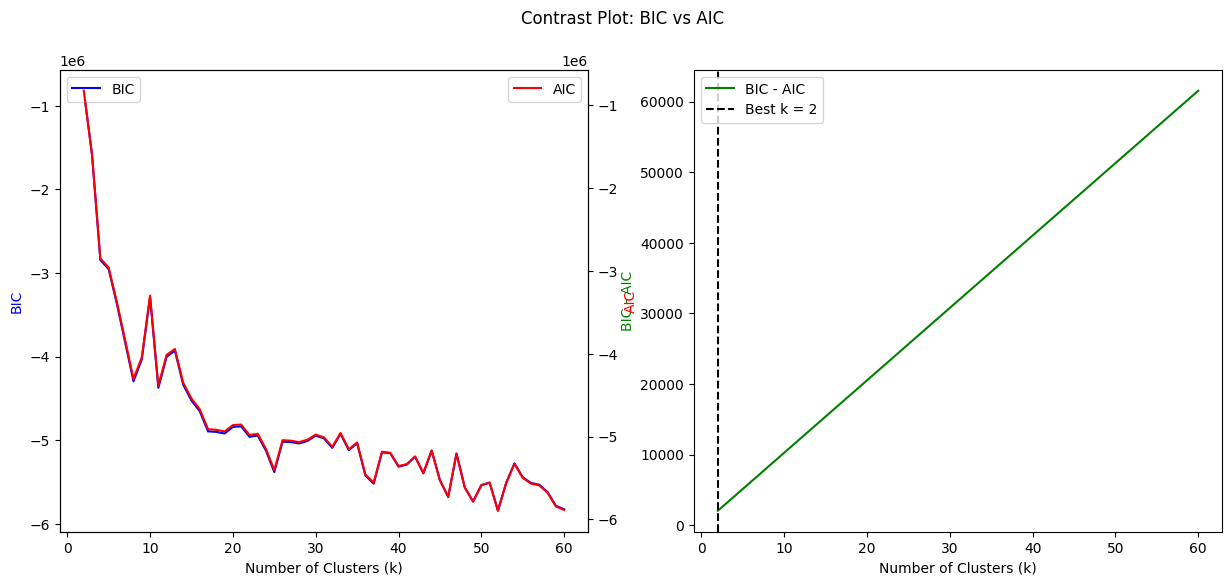

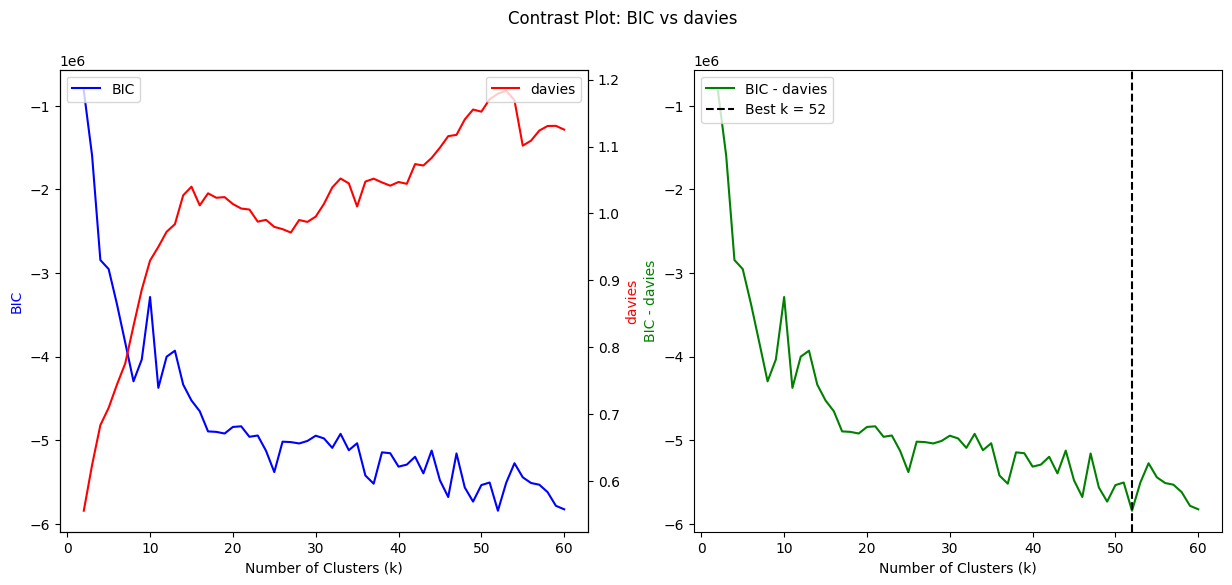

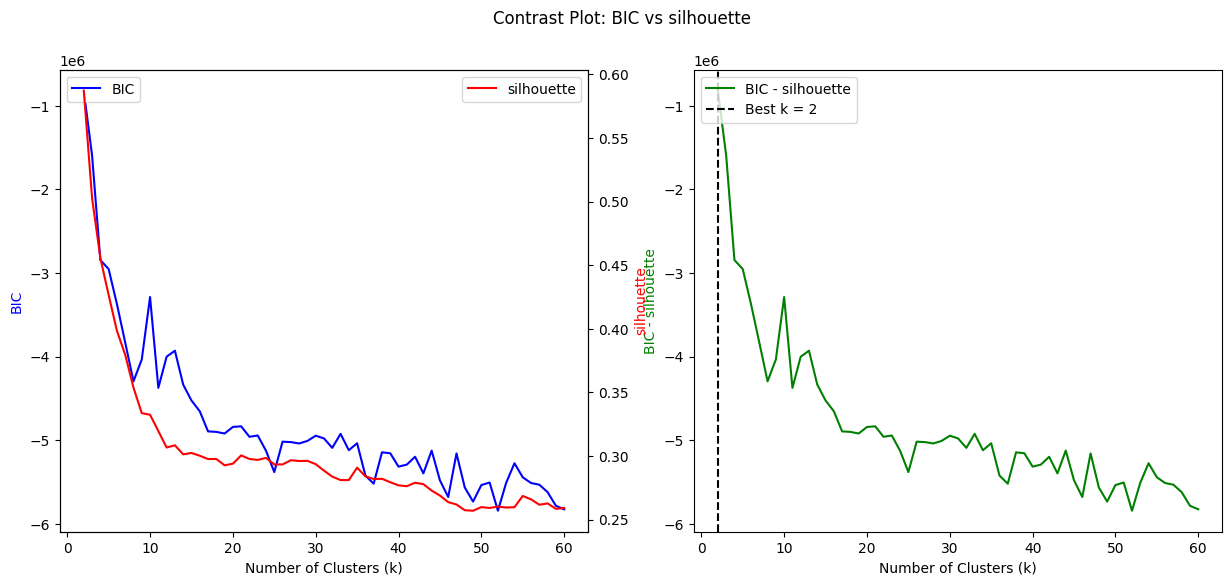

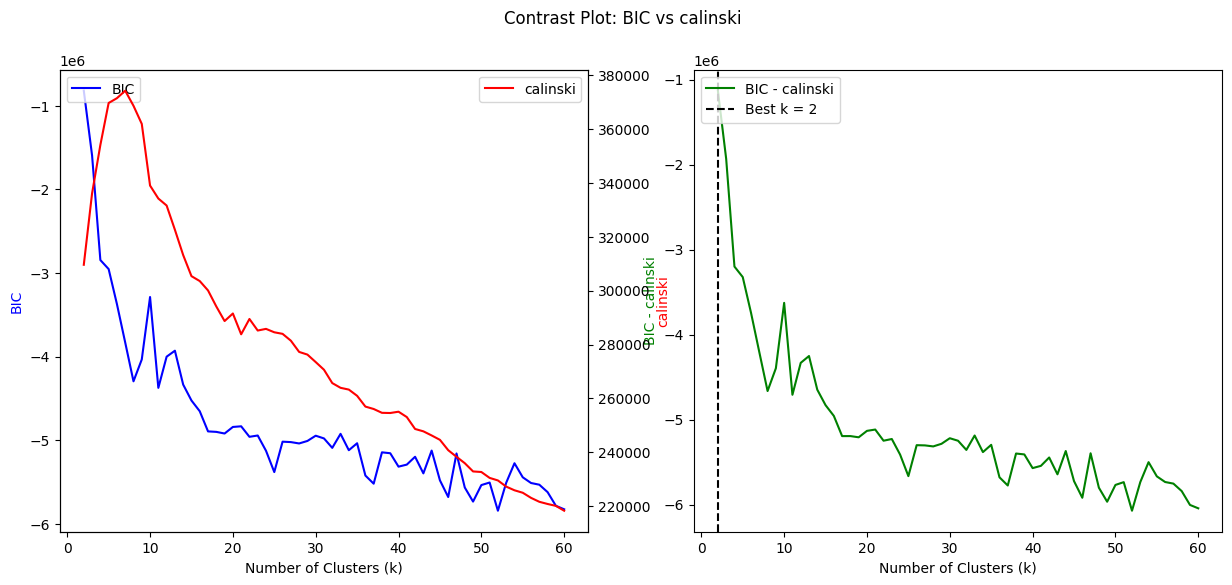

In [41]:
plot_contrast(infc_kmeans_no_scale, 'BIC', 'AIC', 'min')
plot_contrast(infc_kmeans_no_scale, 'BIC', 'davies', 'min')
plot_contrast(infc_kmeans_no_scale, 'BIC', 'silhouette', 'max')
plot_contrast(infc_kmeans_no_scale, 'BIC', 'calinski', 'max')

### GMM Contrast

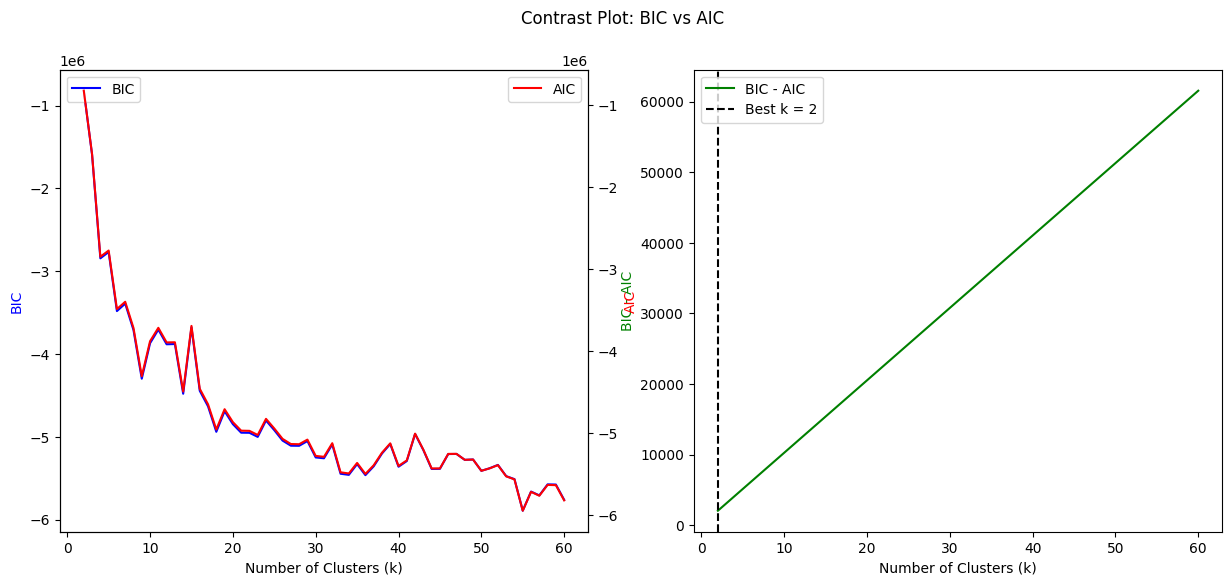

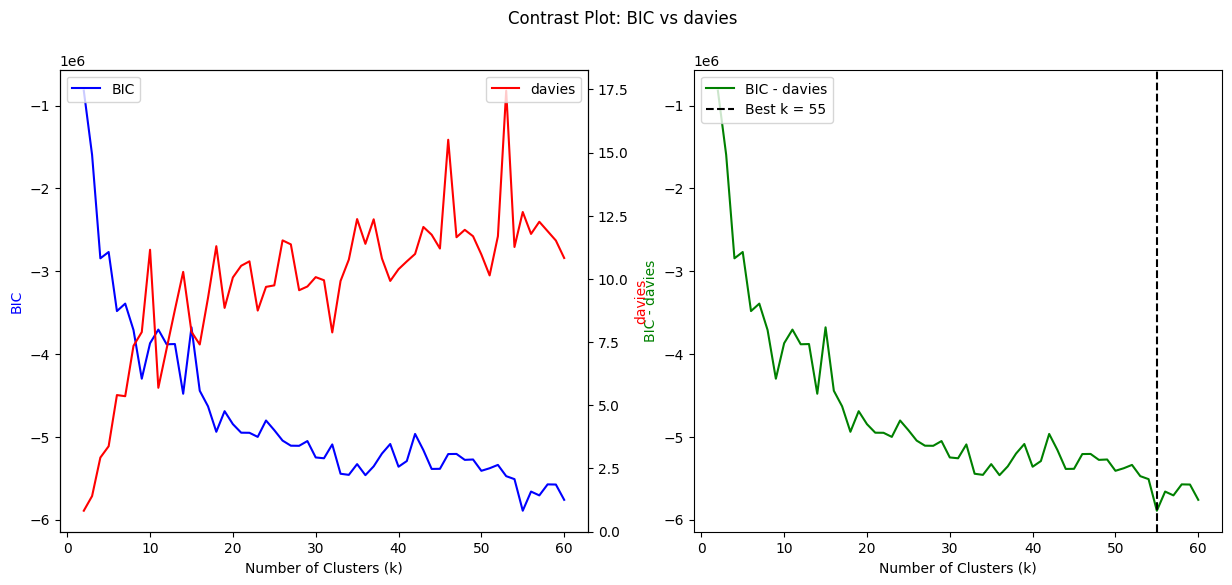

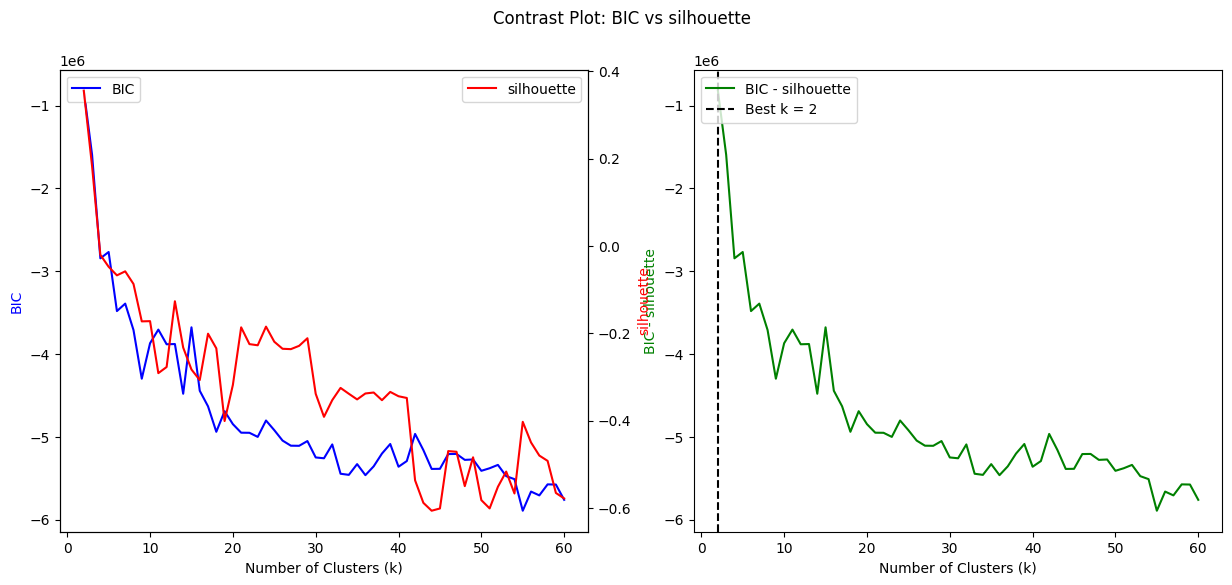

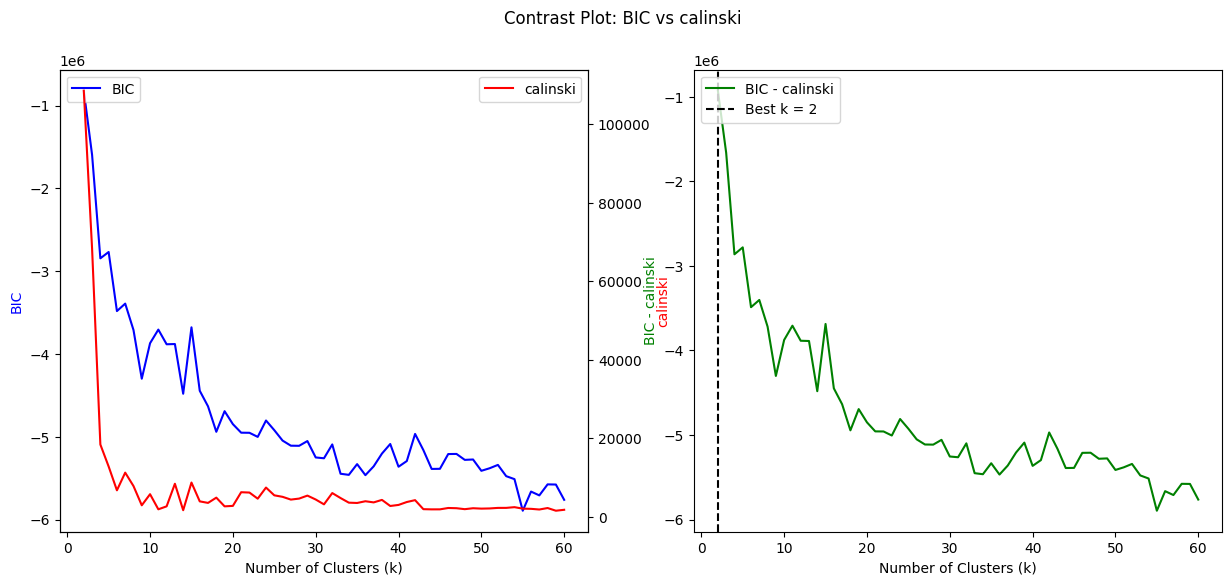

In [42]:
plot_contrast(infc_gmm_full_silo, 'BIC', 'AIC', 'min')
plot_contrast(infc_gmm_full_silo, 'BIC', 'davies', 'min')
plot_contrast(infc_gmm_full_silo, 'BIC', 'silhouette', 'max')
plot_contrast(infc_gmm_full_silo, 'BIC', 'calinski', 'max')

### GMM no scale mini test

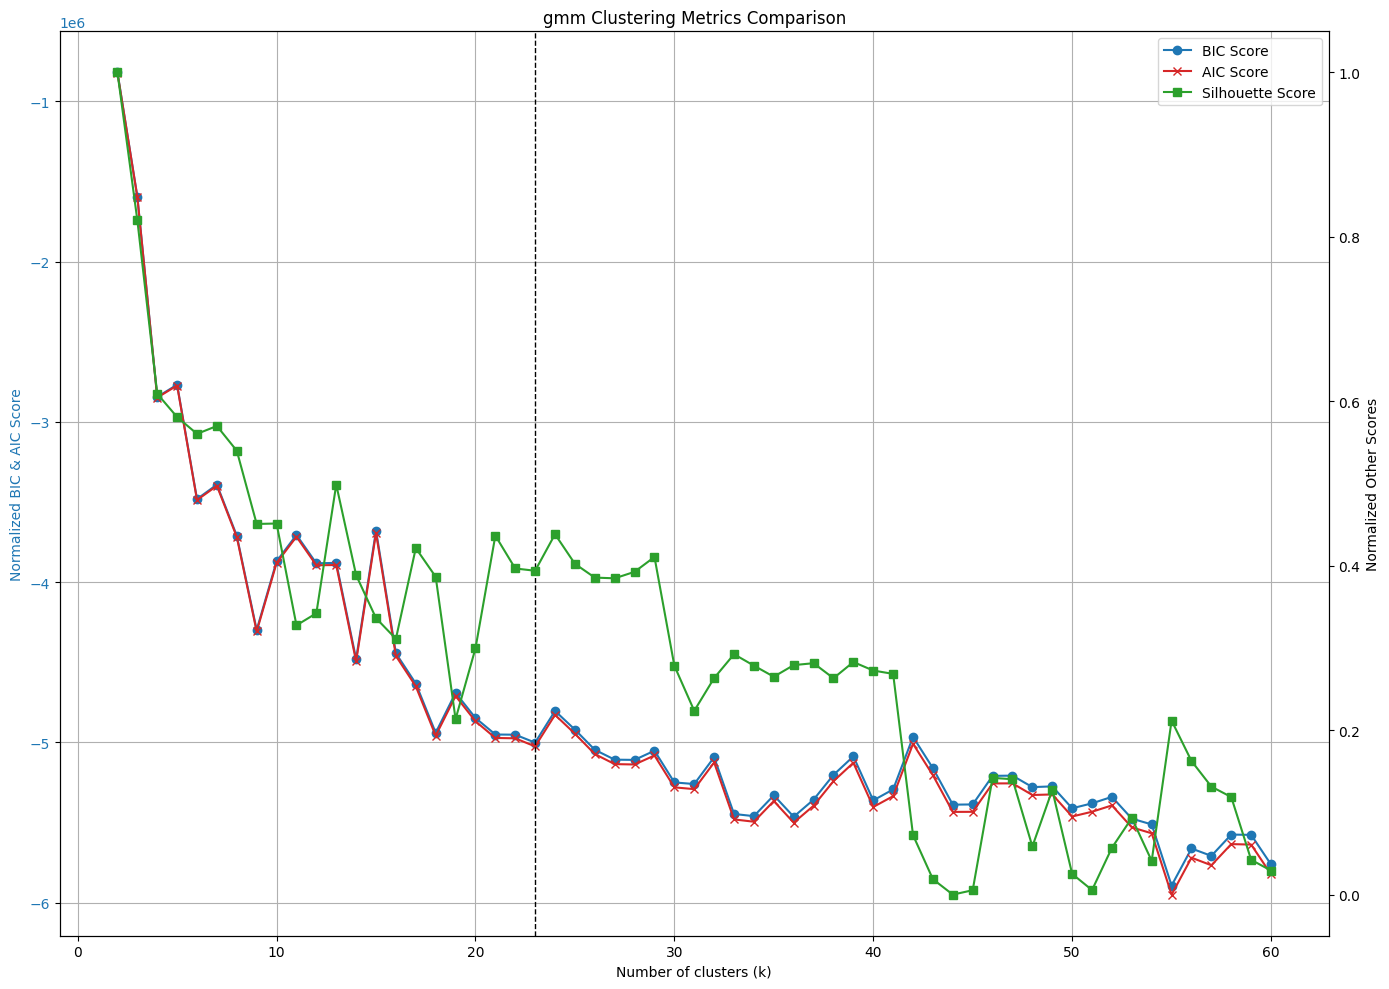

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def normalize_scores(df, columns):
    result = df.copy()
    for column in columns:
        max_val = df[column].max()
        min_val = df[column].min()
        result[column] = (df[column] - min_val) / (max_val - min_val)
    return result

def plot_gmm_scores_mini(infc_gmm, silhouette=False, k=None):
    # Normalize the scores
    columns_to_normalize = ['silhouette']
    infc_gmm_normalized = normalize_scores(infc_gmm, columns_to_normalize)
    
    fig, ax1 = plt.subplots(figsize=(14, 10))
    
    # Plot normalized BIC and AIC on the primary y-axis
    color = 'tab:blue'
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Normalized BIC & AIC Score', color=color)
    ax1.plot(infc_gmm_normalized['k'], infc_gmm_normalized['BIC'], marker='o', color=color, label='BIC Score')
    ax1.plot(infc_gmm_normalized['k'], infc_gmm_normalized['AIC'], marker='x', color='tab:red', label='AIC Score')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create secondary y-axis to plot the other normalized metrics
    ax2 = ax1.twinx()
    ax2.set_ylabel('Normalized Other Scores')
    
    if silhouette:
        ax2.plot(infc_gmm_normalized['k'], infc_gmm_normalized['silhouette'], marker='s', color='tab:green', label='Silhouette Score')
        
    ax2.tick_params(axis='y')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Create a custom legend for the vertical line
    if k is not None:
        custom_line = Line2D([0], [0], color='black', linestyle='--', linewidth=1)
        lines1.append(custom_line)
        labels1.append('Estimated Optimal K')

    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    # Adding a dotted black line at x = k if k is provided
    if k is not None:
        ax1.axvline(x=k, color='black', linestyle='--', linewidth=1)

    # Adding legends manually
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    # Titles and grid
    plt.title('gmm Clustering Metrics Comparison')
    ax1.grid(True)
    plt.tight_layout()
    plt.show()


plot_gmm_scores_mini(infc_gmm_full_silo, silhouette=True, k=23)